# Binary black hole orbital phase

This notebook demonstrates the model, Kepler solver, phase evolution, and detection of times where $\phi = i\pi$.

The workflow is: evolve the mean anomaly $l(t)$, solve $l = u - e_t\sin(u)$, compute the true anomaly $v$, and then evaluate $\phi = \phi_0 + (1+k)v$.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Find src/ from the notebook's current directory.
for root in (Path.cwd(), *Path.cwd().parents):
    if (root / "src" / "oj287_sim" / "main.py").exists():
        sys.path.insert(0, str(root / "src"))
        break
else:
    raise FileNotFoundError("src/oj287_sim/main.py not found")

from oj287_sim.main import simulate_orbit
from oj287_sim.model import BBHModel
from oj287_sim.solver import solve_kepler

/home/user/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
    # t and t0 are years; n, n_dot, n_ddot use rad/year, rad/year^2, rad/year^3.
    m = BBHModel(
        phi0=0.0,
        k=0.02,
        e_phi=0.3,
        l0=0.0,
        n=0.8,
        n_dot=0.0001,
        n_ddot=-0.00005,
        # n_dot=0.0,
        # n_ddot=0.0,
        t0=1912.0,
        e_t=0.3,
    )
    
    t = np.linspace(1912.0, 1960.0, 20000)
    # t = np.linspace(2015.0, 2025.0, 2001)
    r = simulate_orbit(m, t)
    
    print(f"samples: {len(r['t'])}")
    print(f"crossings: {len(r['phase_crossings'])}")
    print("crossing years:", r["phase_crossings"])
    r["phase_crossings"]

samples: 20000
crossings: 12
crossing years: [1915.79032104 1919.77590431 1923.38097386 1927.57319984 1931.01090733
 1935.42167562 1938.7122656  1943.35313522 1946.51937525 1951.40282549
 1954.47020526 1959.6112947 ]


array([1915.79032104, 1919.77590431, 1923.38097386, 1927.57319984,
       1931.01090733, 1935.42167562, 1938.7122656 , 1943.35313522,
       1946.51937525, 1951.40282549, 1954.47020526, 1959.6112947 ])

In [3]:
# One direct solver call for the equation l = u - e*sin(u).
ll = 1.0
uu = solve_kepler(ll, m.e_t)
print(f"l={ll:.3f}, e={m.e_t:.3f}, u={uu:.12f}")
print(f"residual={uu - m.e_t * np.sin(uu) - ll:.3e}")

l=1.000, e=0.300, u=1.288091313212
residual=0.000e+00


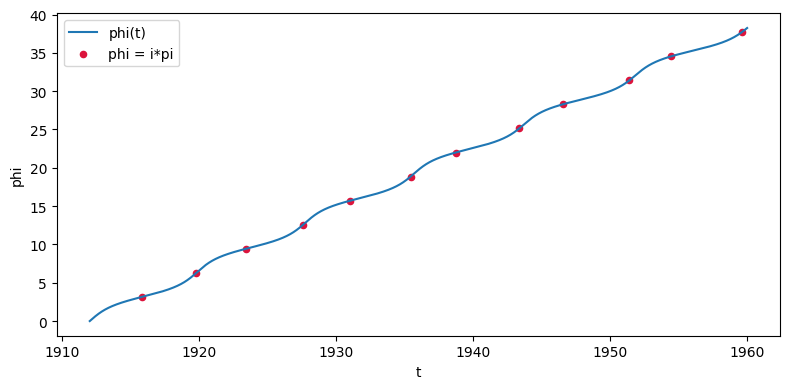

In [4]:
cross = r["phase_crossings"]
plt.figure(figsize=(8, 4))
plt.plot(r["t"], r["phi"], label="phi(t)")
plt.scatter(cross, np.interp(cross, r["t"], r["phi"]), color="crimson", s=20, label="phi = i*pi")
plt.xlabel("t")
plt.ylabel("phi")
plt.legend()
plt.tight_layout()
plt.show()

The crossing times are estimated by linear interpolation between neighboring time samples. For higher precision, reduce the time spacing or refine each event with a scalar root finder.